In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import joblib
import os

df = pd.read_csv('TARP.csv')
print(df.shape)
print(df.head())
print(df.columns.tolist())
print(df.isnull().sum())

(100000, 15)
   Soil Moisture  Temperature   Soil Humidity  Time  Air temperature (C)  \
0             54           22              70    21                19.52   
1             12           20              40   104                19.49   
2             34           26              35    62                19.47   
3              7           44              44    93                19.54   
4             50           38              23    92                19.61   

   Wind speed (Km/h)  Air humidity (%)  Wind gust (Km/h)  Pressure (KPa)  \
0               2.13             55.04              6.30          101.50   
1               2.01             55.17             10.46          101.50   
2               1.90             55.30             14.63          101.51   
3               2.28             54.20             16.08          101.51   
4               2.66             53.09             17.52          101.51   

         ph    rainfall     N     P     K Status  
0  6.502985  202.93553

In [7]:
print(df.dtypes)
print(df.describe())
print("\nTarget column (last):", df.columns[-1])
print(df[df.columns[-1]].value_counts())

Soil Moisture            int64
Temperature              int64
 Soil Humidity           int64
Time                     int64
Air temperature (C)    float64
Wind speed (Km/h)      float64
Air humidity (%)       float64
Wind gust (Km/h)       float64
Pressure (KPa)         float64
ph                     float64
rainfall               float64
N                      float64
P                      float64
K                      float64
Status                     str
dtype: object
       Soil Moisture    Temperature   Soil Humidity           Time  \
count  100000.000000  100000.000000   100000.000000  100000.000000   
mean       45.484070      22.536100       45.016790      55.253650   
std        25.993998      13.251352       14.726676      32.093033   
min         1.000000       0.000000       20.000000       0.000000   
25%        23.000000      11.000000       32.000000      28.000000   
50%        45.000000      23.000000       45.000000      55.000000   
75%        68.000000      34.00

In [8]:
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

target_col = df.columns[-1]
X = df.drop(target_col, axis=1)
y = df[target_col]
feat_names = X.columns.tolist()
print(f"Features: {feat_names}")
print(f"Target: {target_col}")

Features: ['Soil Moisture', 'Temperature', ' Soil Humidity', 'Time', 'Air temperature (C)', 'Wind speed (Km/h)', 'Air humidity (%)', 'Wind gust (Km/h)', 'Pressure (KPa)', 'ph', 'rainfall', 'N', 'P', 'K']
Target: Status


C:\Users\Rupayan\AppData\Local\Temp\ipykernel_37972\3330050879.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


Accuracy: 99.41%
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      9305
           1       0.99      1.00      0.99     10695

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000



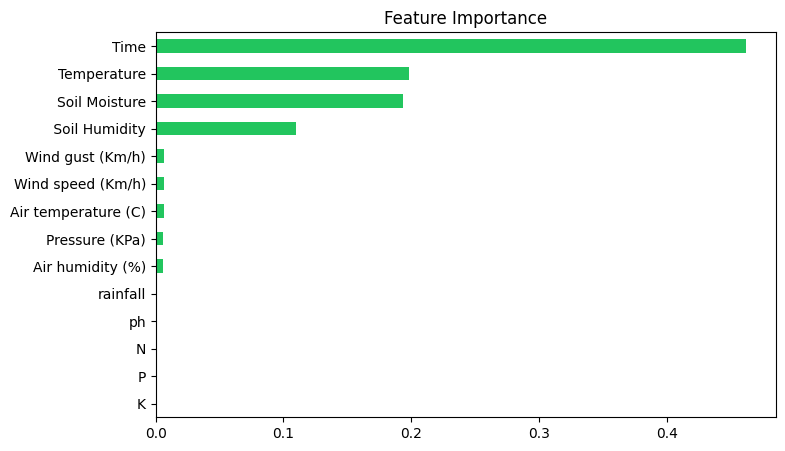

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)
acc = accuracy_score(y_test, preds)
print(f"Accuracy: {acc:.2%}")
print(classification_report(y_test, preds))

importances = pd.Series(model.feature_importances_, index=feat_names)
importances.sort_values().plot(kind='barh', figsize=(8,5), color='#22c55e')
plt.title('Feature Importance')
plt.show()

In [10]:
os.makedirs('../backend/models', exist_ok=True)
joblib.dump(model, '../backend/models/irrigation_model.pkl')
joblib.dump(feat_names, '../backend/models/feature_names.pkl')
print("Model saved!")
print(f"Features saved: {feat_names}")

Model saved!
Features saved: ['Soil Moisture', 'Temperature', ' Soil Humidity', 'Time', 'Air temperature (C)', 'Wind speed (Km/h)', 'Air humidity (%)', 'Wind gust (Km/h)', 'Pressure (KPa)', 'ph', 'rainfall', 'N', 'P', 'K']
